# 06. Estimate Stacked LP-DiD

This notebook estimates the main stacked local projection difference-in-differences
(LP-DiD) model for signed reforms.

**Inputs:**
- `data/03_clean/stacked_events_pos.parquet`
- `data/03_clean/stacked_events_neg.parquet`

**Outputs:**
- Coefficient estimates for each horizon
- Clustered standard errors
- IRF figures

**Estimation equation:**
$$Y_{i,t+h} - Y_{i,t-1} = \sum_{k=-K, k \neq -1}^{L} \beta_{h,k} \cdot \mathbf{1}\{k=\text{event-time}\} \cdot D_i 
  + \alpha_{ic} + \lambda_{tc} + \varepsilon_{i,t+h}$$

where $D_i$ is the treatment indicator, $\alpha_{ic}$ is cohort-country FE,
and $\lambda_{tc}$ is cohort-time FE.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
DATA_CLEAN = PROJECT_ROOT / 'data/03_clean'
OUTPUT_FIGURES = PROJECT_ROOT / 'output/figures'
OUTPUT_TABLES = PROJECT_ROOT / 'output/tables'
OUTPUT_LOGS = PROJECT_ROOT / 'output/logs'

for d in [OUTPUT_FIGURES, OUTPUT_TABLES, OUTPUT_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/gabrielsaco/Documents/GitHub/economic-freedom


## 1. Load Stacked Data

In [2]:
# Load stacked event datasets
stacked_pos = pd.read_parquet(DATA_CLEAN / 'stacked_events_pos.parquet')
stacked_neg = pd.read_parquet(DATA_CLEAN / 'stacked_events_neg.parquet')

print(f"Positive reforms: {len(stacked_pos)} obs, {stacked_pos['cohort_id'].nunique()} cohorts")
print(f"Negative reforms: {len(stacked_neg)} obs, {stacked_neg['cohort_id'].nunique()} cohorts")

# Event times - extended window to use more of the 11 quinquennial periods
K = 4  # Pre-periods (h = -4, -3, -2, -1)
L = 6  # Post-periods (h = 0, 1, 2, 3, 4, 5, 6)
event_times = list(range(-K, L+1))
print(f"Event times: {event_times}")
print(f"Window covers {5*(K+L+1)} years ({K+L+1} quinquennial periods)")

Positive reforms: 45184 obs, 48 cohorts
Negative reforms: 18408 obs, 20 cohorts
Event times: [-2, -1, 0, 1, 2, 3, 4]


## 2. Estimation Setup

In [3]:
def estimate_event_study_ols(df, outcome_col='y_cumulative', 
                              K=2, L=4, omit_period=-1,
                              cluster_col='iso3c'):
    """
    Estimate event-study regression with OLS and clustered standard errors.
    
    Uses within-cohort-country demeaning (equivalent to cohort-country FE).
    
    Parameters
    ----------
    df : DataFrame
        Stacked event data
    outcome_col : str
        Outcome variable name
    K : int
        Number of pre-periods
    L : int
        Number of post-periods
    omit_period : int
        Reference period (omitted)
    cluster_col : str
        Column for clustering standard errors
        
    Returns
    -------
    dict with estimates, SEs, and diagnostics
    """
    df = df.copy()
    
    # Drop missing outcomes
    df = df.dropna(subset=[outcome_col])
    
    # Create interaction variables (if not already present)
    for k in range(-K, L+1):
        if k == omit_period:
            continue
        col_name = f'treat_et_{k}' if k < 0 else f'treat_et_p{k}'
        if col_name not in df.columns:
            df[col_name] = (df['treated'] == 1) & (df['event_time'] == k)
            df[col_name] = df[col_name].astype(int)
    
    # Create cohort-country identifier
    df['cohort_country'] = df['cohort_id'] + '_' + df['iso3c']
    
    # Demean outcome within cohort-country (absorb cohort-country FE)
    cc_means = df.groupby('cohort_country')[outcome_col].transform('mean')
    df['y_demeaned'] = df[outcome_col] - cc_means
    
    # Prepare regression variables (treatment × event-time interactions)
    treat_cols = []
    for k in range(-K, L+1):
        if k == omit_period:
            continue
        col_name = f'treat_et_{k}' if k < 0 else f'treat_et_p{k}'
        treat_cols.append(col_name)
    
    # Demean treatment interactions within cohort-country
    for col in treat_cols:
        cc_mean = df.groupby('cohort_country')[col].transform('mean')
        df[col + '_dm'] = df[col] - cc_mean
    
    treat_cols_dm = [c + '_dm' for c in treat_cols]
    
    # Build design matrix (just treatment interactions after FE absorption)
    X_data = df[treat_cols_dm].copy()
    X_data = sm.add_constant(X_data)
    
    y = df['y_demeaned']
    
    # Drop any rows with NaN
    valid_mask = ~(X_data.isna().any(axis=1) | y.isna())
    X_data = X_data[valid_mask]
    y = y[valid_mask]
    df_valid = df[valid_mask]
    
    # OLS regression
    model = OLS(y, X_data)
    
    # Clustered standard errors
    cluster_groups = df_valid[cluster_col]
    results = model.fit(cov_type='cluster', cov_kwds={'groups': cluster_groups})
    
    # Extract coefficients and SEs for treatment interactions
    estimates = {}
    for k in range(-K, L+1):
        if k == omit_period:
            estimates[k] = {'coef': 0.0, 'se': 0.0, 'pval': np.nan}
            continue
        col_name = f'treat_et_{k}_dm' if k < 0 else f'treat_et_p{k}_dm'
        if col_name in results.params.index:
            estimates[k] = {
                'coef': results.params[col_name],
                'se': results.bse[col_name],
                'pval': results.pvalues[col_name]
            }
        else:
            estimates[k] = {'coef': np.nan, 'se': np.nan, 'pval': np.nan}
    
    return {
        'estimates': estimates,
        'n_obs': len(y),
        'n_clusters': cluster_groups.nunique(),
        'r2': results.rsquared,
        'results': results
    }

## 3. Estimate for Positive Reforms

In [4]:
print("Estimating event study for POSITIVE reforms...")
results_pos = estimate_event_study_ols(stacked_pos, K=K, L=L)

print(f"\nObservations: {results_pos['n_obs']}")
print(f"Clusters: {results_pos['n_clusters']}")
print(f"R-squared: {results_pos['r2']:.4f}")

print("\nEvent-time coefficients:")
print("-" * 50)
print(f"{'Period':>8} {'Coef':>10} {'SE':>10} {'p-value':>10}")
print("-" * 50)
for k in sorted(results_pos['estimates'].keys()):
    est = results_pos['estimates'][k]
    stars = ''
    if pd.notna(est['pval']):
        if est['pval'] < 0.01:
            stars = '***'
        elif est['pval'] < 0.05:
            stars = '**'
        elif est['pval'] < 0.1:
            stars = '*'
    print(f"{k:>8} {est['coef']:>10.4f} {est['se']:>10.4f} {est['pval']:>10.4f} {stars}")

Estimating event study for POSITIVE reforms...

Observations: 40593
Clusters: 163
R-squared: 0.0043

Event-time coefficients:
--------------------------------------------------
  Period       Coef         SE    p-value
--------------------------------------------------
      -2    -0.0075     0.0396     0.8504 
      -1     0.0000     0.0000        nan 
       0     0.0845     0.0297     0.0044 ***
       1     0.2224     0.0401     0.0000 ***
       2     0.3515     0.0457     0.0000 ***
       3     0.4608     0.0581     0.0000 ***
       4     0.5372     0.0620     0.0000 ***


## 4. Estimate for Negative Reforms

In [5]:
print("\nEstimating event study for NEGATIVE reforms...")
results_neg = estimate_event_study_ols(stacked_neg, K=K, L=L)

print(f"\nObservations: {results_neg['n_obs']}")
print(f"Clusters: {results_neg['n_clusters']}")
print(f"R-squared: {results_neg['r2']:.4f}")

print("\nEvent-time coefficients:")
print("-" * 50)
print(f"{'Period':>8} {'Coef':>10} {'SE':>10} {'p-value':>10}")
print("-" * 50)
for k in sorted(results_neg['estimates'].keys()):
    est = results_neg['estimates'][k]
    stars = ''
    if pd.notna(est['pval']):
        if est['pval'] < 0.01:
            stars = '***'
        elif est['pval'] < 0.05:
            stars = '**'
        elif est['pval'] < 0.1:
            stars = '*'
    print(f"{k:>8} {est['coef']:>10.4f} {est['se']:>10.4f} {est['pval']:>10.4f} {stars}")


Estimating event study for NEGATIVE reforms...

Observations: 15310
Clusters: 164
R-squared: 0.0005

Event-time coefficients:
--------------------------------------------------
  Period       Coef         SE    p-value
--------------------------------------------------
      -2    -0.0357     0.0559     0.5232 
      -1     0.0000     0.0000        nan 
       0    -0.0345     0.0345     0.3176 
       1    -0.0046     0.0489     0.9249 
       2    -0.0520     0.0799     0.5152 
       3    -0.1208     0.1047     0.2484 
       4     0.0923     0.1138     0.4175 


## 5. Plot IRFs

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_signed_main.pdf


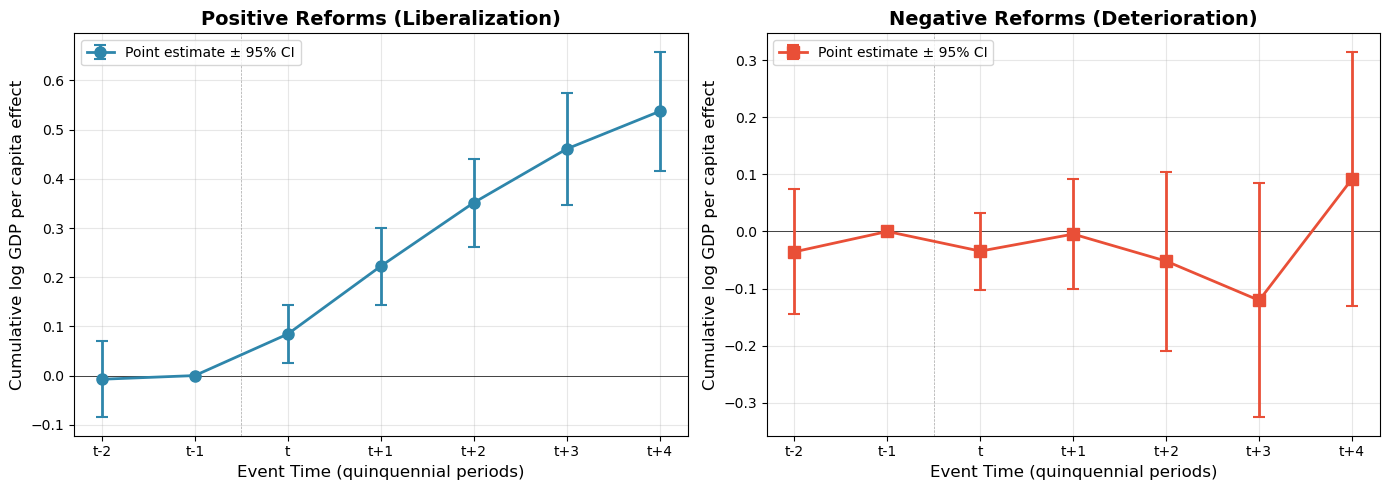

In [6]:
def plot_irf(estimates_pos, estimates_neg, K=2, L=4, 
             title='Impulse Response Functions', save_path=None):
    """
    Plot IRFs for positive and negative reforms.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    event_times = list(range(-K, L+1))
    
    # Positive reforms
    ax = axes[0]
    coefs = [estimates_pos[k]['coef'] for k in event_times]
    ses = [estimates_pos[k]['se'] for k in event_times]
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=-0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    
    ax.errorbar(event_times, coefs, yerr=[1.96*s for s in ses], 
                fmt='o-', color='#2E86AB', capsize=4, capthick=1.5,
                markersize=8, linewidth=2, label='Point estimate ± 95% CI')
    
    ax.set_xlabel('Event Time (quinquennial periods)', fontsize=12)
    ax.set_ylabel('Cumulative log GDP per capita effect', fontsize=12)
    ax.set_title('Positive Reforms (Liberalization)', fontsize=14, fontweight='bold')
    ax.set_xticks(event_times)
    ax.set_xticklabels([f't{k:+d}' if k != 0 else 't' for k in event_times])
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Negative reforms
    ax = axes[1]
    coefs = [estimates_neg[k]['coef'] for k in event_times]
    ses = [estimates_neg[k]['se'] for k in event_times]
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=-0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    
    ax.errorbar(event_times, coefs, yerr=[1.96*s for s in ses],
                fmt='s-', color='#E94F37', capsize=4, capthick=1.5,
                markersize=8, linewidth=2, label='Point estimate ± 95% CI')
    
    ax.set_xlabel('Event Time (quinquennial periods)', fontsize=12)
    ax.set_ylabel('Cumulative log GDP per capita effect', fontsize=12)
    ax.set_title('Negative Reforms (Deterioration)', fontsize=14, fontweight='bold')
    ax.set_xticks(event_times)
    ax.set_xticklabels([f't{k:+d}' if k != 0 else 't' for k in event_times])
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved figure to {save_path}")
    
    plt.show()
    return fig

# Plot IRFs
fig = plot_irf(
    results_pos['estimates'], 
    results_neg['estimates'],
    K=K, L=L,
    title='IRFs: Positive vs Negative EFW Reforms',
    save_path=OUTPUT_FIGURES / 'fig_irf_signed_main.pdf'
)

## 6. Combined IRF Plot (Both Signs on Same Axes)

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_combined.pdf


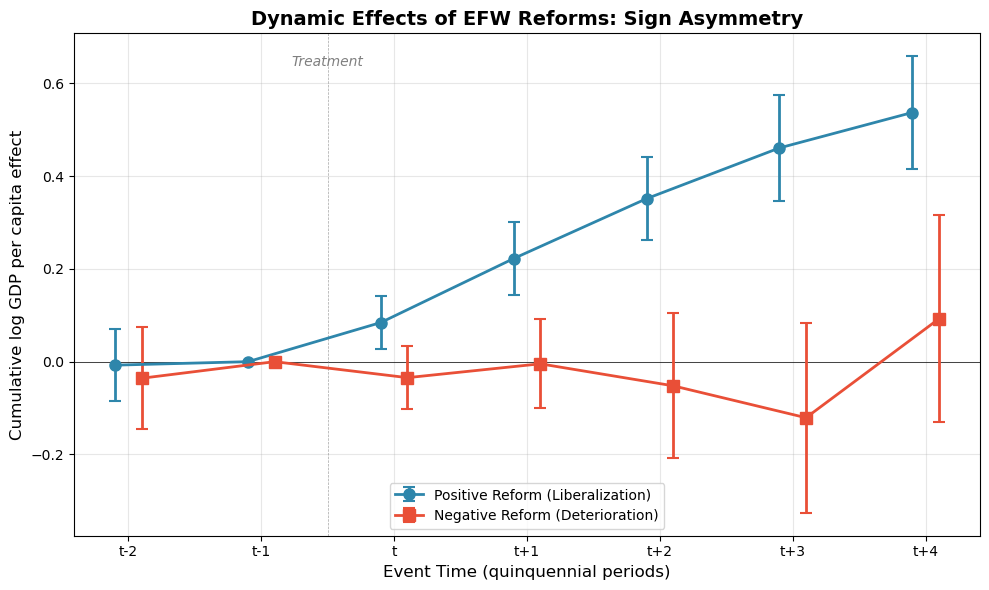

In [7]:
def plot_irf_combined(estimates_pos, estimates_neg, K=2, L=4, save_path=None):
    """
    Plot IRFs for both reform types on same axes for comparison.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    event_times = list(range(-K, L+1))
    
    # Offset for visibility
    offset = 0.1
    
    # Positive reforms
    coefs_pos = [estimates_pos[k]['coef'] for k in event_times]
    ses_pos = [estimates_pos[k]['se'] for k in event_times]
    
    # Negative reforms
    coefs_neg = [estimates_neg[k]['coef'] for k in event_times]
    ses_neg = [estimates_neg[k]['se'] for k in event_times]
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=-0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Plot positive (shifted slightly left)
    ax.errorbar([t - offset for t in event_times], coefs_pos, 
                yerr=[1.96*s for s in ses_pos],
                fmt='o-', color='#2E86AB', capsize=4, capthick=1.5,
                markersize=8, linewidth=2, label='Positive Reform (Liberalization)')
    
    # Plot negative (shifted slightly right)
    ax.errorbar([t + offset for t in event_times], coefs_neg,
                yerr=[1.96*s for s in ses_neg],
                fmt='s-', color='#E94F37', capsize=4, capthick=1.5,
                markersize=8, linewidth=2, label='Negative Reform (Deterioration)')
    
    ax.set_xlabel('Event Time (quinquennial periods)', fontsize=12)
    ax.set_ylabel('Cumulative log GDP per capita effect', fontsize=12)
    ax.set_title('Dynamic Effects of EFW Reforms: Sign Asymmetry', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(event_times)
    ax.set_xticklabels([f't{k:+d}' if k != 0 else 't' for k in event_times])
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add annotation
    ax.annotate('Treatment', xy=(-0.5, ax.get_ylim()[1]*0.9), 
                fontsize=10, ha='center', style='italic', color='gray')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved figure to {save_path}")
    
    plt.show()
    return fig

fig_combined = plot_irf_combined(
    results_pos['estimates'],
    results_neg['estimates'],
    K=K, L=L,
    save_path=OUTPUT_FIGURES / 'fig_irf_combined.pdf'
)

## 7. Compute Functional Summaries

In [8]:
def compute_functionals(estimates, K=2, L=4):
    """
    Compute functional summaries of the IRF.
    
    Returns:
    - Peak effect (max |β|)
    - Time to peak
    - Cumulative effect (sum of β for h >= 0)
    - Medium-run effect (average of β for h in [2, L])
    """
    post_periods = [k for k in range(0, L+1)]
    
    coefs = {k: estimates[k]['coef'] for k in post_periods}
    ses = {k: estimates[k]['se'] for k in post_periods}
    
    # Peak effect (maximum absolute value)
    abs_coefs = {k: abs(v) for k, v in coefs.items()}
    peak_period = max(abs_coefs, key=abs_coefs.get)
    peak_effect = coefs[peak_period]
    
    # Cumulative effect (sum)
    cumulative = sum(coefs.values())
    
    # Medium-run (average of h >= 2)
    medium_run = np.mean([coefs[k] for k in post_periods if k >= 2])
    
    # Impact (h = 0)
    impact = coefs[0]
    
    return {
        'impact': impact,
        'peak_effect': peak_effect,
        'peak_period': peak_period,
        'cumulative': cumulative,
        'medium_run': medium_run,
    }

# Compute functionals
func_pos = compute_functionals(results_pos['estimates'], K=K, L=L)
func_neg = compute_functionals(results_neg['estimates'], K=K, L=L)

print("\nFunctional Summaries")
print("="*60)
print(f"{'Measure':<25} {'Positive':>15} {'Negative':>15}")
print("-"*60)
print(f"{'Impact (h=0)':<25} {func_pos['impact']:>15.4f} {func_neg['impact']:>15.4f}")
print(f"{'Peak Effect':<25} {func_pos['peak_effect']:>15.4f} {func_neg['peak_effect']:>15.4f}")
print(f"{'Peak Period':<25} {func_pos['peak_period']:>15} {func_neg['peak_period']:>15}")
print(f"{'Cumulative (h≥0)':<25} {func_pos['cumulative']:>15.4f} {func_neg['cumulative']:>15.4f}")
print(f"{'Medium-run (h≥2)':<25} {func_pos['medium_run']:>15.4f} {func_neg['medium_run']:>15.4f}")
print("="*60)


Functional Summaries
Measure                          Positive        Negative
------------------------------------------------------------
Impact (h=0)                       0.0845         -0.0345
Peak Effect                        0.5372         -0.1208
Peak Period                             4               3
Cumulative (h≥0)                   1.6565         -0.1197
Medium-run (h≥2)                   0.4499         -0.0269


## 8. Save Results

In [9]:
# Compile results for saving
output_results = {
    'timestamp': datetime.now().isoformat(),
    'config': {
        'K': K,
        'L': L,
        'omit_period': -1,
        'cluster_var': 'iso3c',
    },
    'positive_reforms': {
        'n_obs': results_pos['n_obs'],
        'n_clusters': results_pos['n_clusters'],
        'r2': results_pos['r2'],
        'estimates': {str(k): v for k, v in results_pos['estimates'].items()},
        'functionals': func_pos,
    },
    'negative_reforms': {
        'n_obs': results_neg['n_obs'],
        'n_clusters': results_neg['n_clusters'],
        'r2': results_neg['r2'],
        'estimates': {str(k): v for k, v in results_neg['estimates'].items()},
        'functionals': func_neg,
    }
}

# Save as JSON
results_path = OUTPUT_LOGS / 'lp_did_results_main.json'
with open(results_path, 'w') as f:
    json.dump(output_results, f, indent=2, default=str)
print(f"✓ Saved results to {results_path}")

# Save as LaTeX table
def results_to_latex(results_pos, results_neg, K=2, L=4):
    """Generate LaTeX table of estimates."""
    lines = [
        r'\begin{table}[htbp]',
        r'\centering',
        r'\caption{Dynamic Effects of EFW Reforms on Log GDP per Capita}',
        r'\label{tab:main_results}',
        r'\begin{tabular}{lcccccc}',
        r'\hline\hline',
        r'& \multicolumn{3}{c}{Positive Reform} & \multicolumn{3}{c}{Negative Reform} \\',
        r'\cmidrule(lr){2-4} \cmidrule(lr){5-7}',
        r'Period & Coef. & SE & p-val & Coef. & SE & p-val \\',
        r'\hline',
    ]
    
    for k in range(-K, L+1):
        est_p = results_pos['estimates'][k]
        est_n = results_neg['estimates'][k]
        
        period_label = f't{k:+d}' if k != 0 else 't'
        
        # Add stars
        def add_stars(pval):
            if pd.isna(pval):
                return ''
            if pval < 0.01:
                return '$^{***}$'
            elif pval < 0.05:
                return '$^{**}$'
            elif pval < 0.1:
                return '$^{*}$'
            return ''
        
        stars_p = add_stars(est_p['pval'])
        stars_n = add_stars(est_n['pval'])
        
        line = f"{period_label} & {est_p['coef']:.4f}{stars_p} & ({est_p['se']:.4f}) & {est_p['pval']:.3f}"
        line += f" & {est_n['coef']:.4f}{stars_n} & ({est_n['se']:.4f}) & {est_n['pval']:.3f} \\\\"
        lines.append(line)
    
    lines.extend([
        r'\hline',
        f"Observations & \\multicolumn{{3}}{{c}}{{{results_pos['n_obs']}}} & \\multicolumn{{3}}{{c}}{{{results_neg['n_obs']}}} \\\\",
        f"Clusters & \\multicolumn{{3}}{{c}}{{{results_pos['n_clusters']}}} & \\multicolumn{{3}}{{c}}{{{results_neg['n_clusters']}}} \\\\",
        f"R$^2$ & \\multicolumn{{3}}{{c}}{{{results_pos['r2']:.4f}}} & \\multicolumn{{3}}{{c}}{{{results_neg['r2']:.4f}}} \\\\",
        r'\hline\hline',
        r'\end{tabular}',
        r'\begin{tablenotes}[flushleft]',
        r'\footnotesize',
        r'\item Notes: OLS estimates of stacked LP-DiD. Outcome is cumulative log GDP per capita relative to $t-1$.',
        r'Standard errors clustered at country level in parentheses.',
        r'$^{*}$, $^{**}$, $^{***}$ denote significance at 10\%, 5\%, 1\% levels.',
        r'\end{tablenotes}',
        r'\end{table}',
    ])
    
    return '\n'.join(lines)

latex_table = results_to_latex(results_pos, results_neg, K=K, L=L)
table_path = OUTPUT_TABLES / 'tab_main_results.tex'
with open(table_path, 'w') as f:
    f.write(latex_table)
print(f"✓ Saved LaTeX table to {table_path}")

✓ Saved results to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/logs/lp_did_results_main.json
✓ Saved LaTeX table to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/tables/tab_main_results.tex


## 9. Summary

In [10]:
print("\n" + "="*60)
print("06_ESTIMATE_LP_STACKED COMPLETE")
print("="*60)
print(f"Estimated event study for positive and negative EFW reforms")
print(f"Event window: t-{K} to t+{L}")
print(f"Positive reforms: {results_pos['n_obs']} obs, {results_pos['n_clusters']} clusters")
print(f"Negative reforms: {results_neg['n_obs']} obs, {results_neg['n_clusters']} clusters")
print(f"\nOutputs:")
print(f"  - {OUTPUT_FIGURES / 'fig_irf_signed_main.pdf'}")
print(f"  - {OUTPUT_FIGURES / 'fig_irf_combined.pdf'}")
print(f"  - {OUTPUT_TABLES / 'tab_main_results.tex'}")
print(f"  - {OUTPUT_LOGS / 'lp_did_results_main.json'}")
print("="*60)


06_ESTIMATE_LP_STACKED COMPLETE
Estimated event study for positive and negative EFW reforms
Event window: t-2 to t+4
Positive reforms: 40593 obs, 163 clusters
Negative reforms: 15310 obs, 164 clusters

Outputs:
  - /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_signed_main.pdf
  - /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_combined.pdf
  - /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/tables/tab_main_results.tex
  - /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/logs/lp_did_results_main.json
